# Company ESG Financial analysis
## package import

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## import data from csv file

In [38]:
companies = pd.read_csv("data/company_esg_financial_dataset.csv")
companies.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


## Missing values statistics

In [39]:
missing_columns = list(companies.columns[companies.isna().any()])
missing_columns

['GrowthRate']

**_Note_**: The column GrowthRate have missing values.

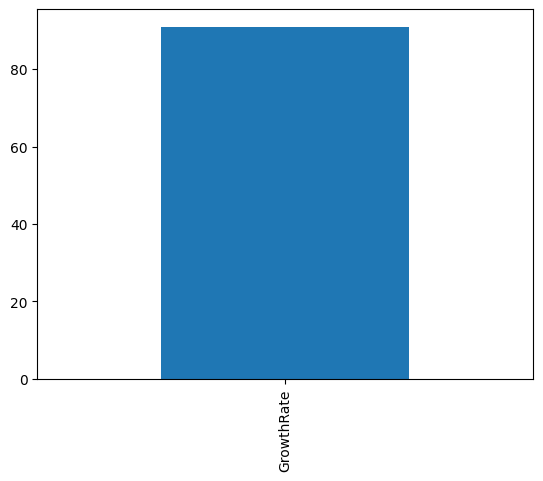

In [40]:
percent_missing_values = companies[missing_columns].agg("count") / companies.shape[0] * 100
percent_missing_values.plot(kind="bar")
plt.show()

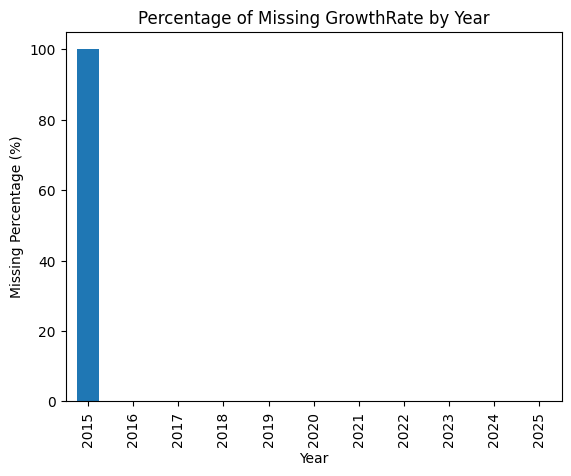

In [41]:
companies.groupby("Year")["GrowthRate"].apply(lambda x: x.isna().mean() * 100).plot(kind="bar")
plt.title("Percentage of Missing GrowthRate by Year")
plt.ylabel("Missing Percentage (%)")
plt.show()

**Remark:**
The GrowthRate variable contains 100% missing values for the year 2015, which represents approximately 90% of the total dataset.

Since the dataset is heavily concentrated in 2015, this variable lacks sufficient coverage to support reliable statistical analysis.

Therefore, the GrowthRate column was removed to preserve analytical consistency and avoid biased conclusions.

In [44]:
companies_cleaned = companies.drop(columns=missing_columns)
companies_cleaned.isna().any()

CompanyID            False
CompanyName          False
Industry             False
Region               False
Year                 False
Revenue              False
ProfitMargin         False
MarketCap            False
ESG_Overall          False
ESG_Environmental    False
ESG_Social           False
ESG_Governance       False
CarbonEmissions      False
WaterUsage           False
EnergyConsumption    False
dtype: bool

## 1. Quels secteurs ont le meilleur score ESG moyen ?
**Objectif**: Identifier les secteurs les plus durables pour guider les décisions d’investissement responsable.

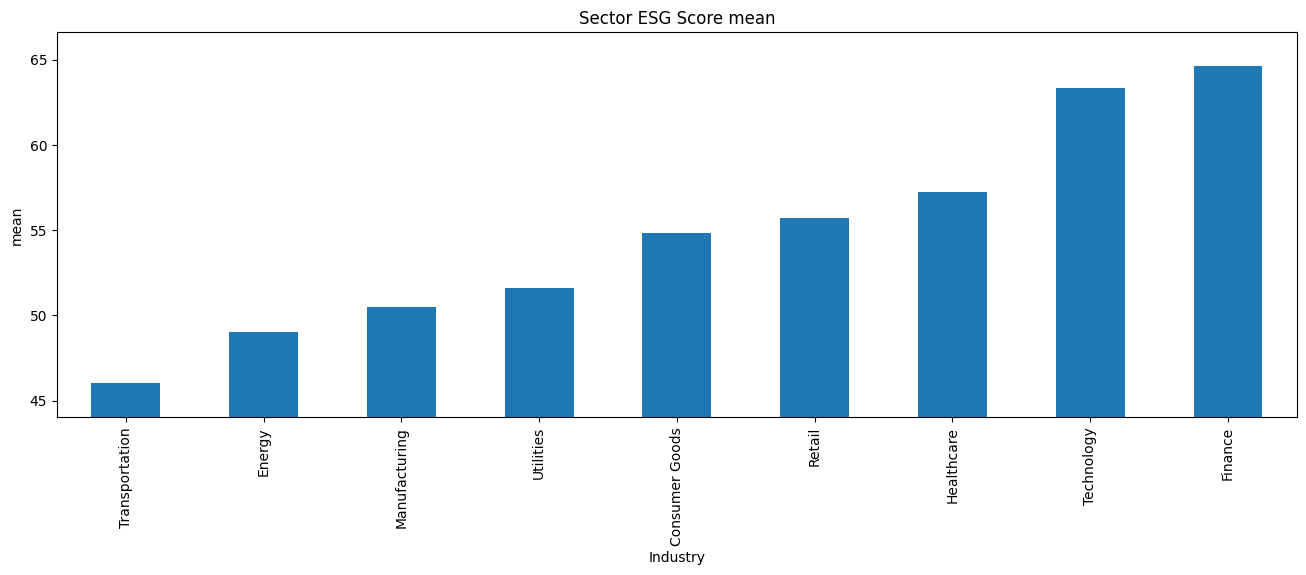

In [62]:
sector_mean = companies_cleaned.groupby("Industry")[["ESG_Overall"]].agg("mean").sort_values(by="ESG_Overall")
plt.figure(figsize=(16,5))
sector_mean["ESG_Overall"].plot(kind="bar")
plt.title("Sector ESG Score mean")
plt.ylabel("mean")
plt.ylim(sector_mean["ESG_Overall"].min() - 2, sector_mean["ESG_Overall"].max() + 2)
plt.show()

**Note:**
This bar chart suggests that companies in the **Financial industry** tend to have the **highest ESG scores**, whereas those in the **Transportation industry** have the **lowest scores**.

This observation highlights potential differences in sustainability practices across industries and can guide further analysis or investment decisions.

## 2. Les entreprises avec un score ESG élevé sont-elles plus rentables ?
**Objectif**: Tester si la durabilité est associée à une meilleure performance financière.

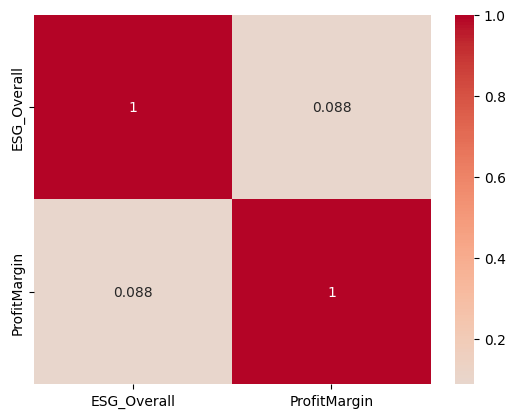

In [68]:
import seaborn as sns
rentabilities = companies_cleaned[["ProfitMargin", "ESG_Overall", "CompanyName", "Industry"]]
corr_matrix = rentabilities[["ESG_Overall", "ProfitMargin"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",center=0)
plt.show()

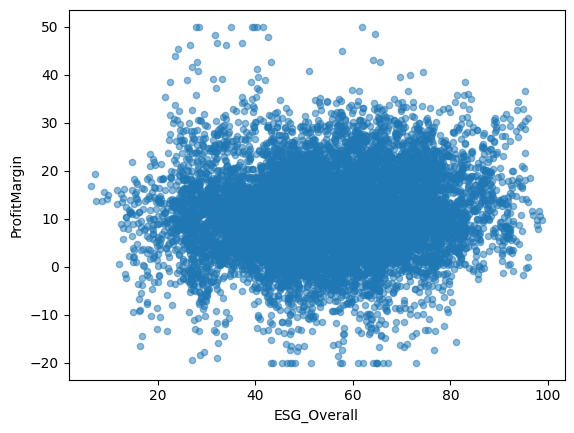

In [71]:
rentabilities.plot(x="ESG_Overall", y="ProfitMargin", alpha=0.5, kind="scatter")
plt.show()

**Note:**
The Pearson correlation between **ProfitMargin** and **ESG score** is **0.088**, which is very low. This indicates that there is **no strong linear relationship** between profitability and ESG performance.

To capture potential non-linear relationships, we could consider using **mutual information scores** or other non-linear dependence measures.

In [80]:
!pip uninstall scikit-learn

^C


## 3. Quelles régions combinent forte performance ESG et forte capitalisation boursière ?
**Objectif**: Identifier les zones géographiques attractives pour investissement durable.

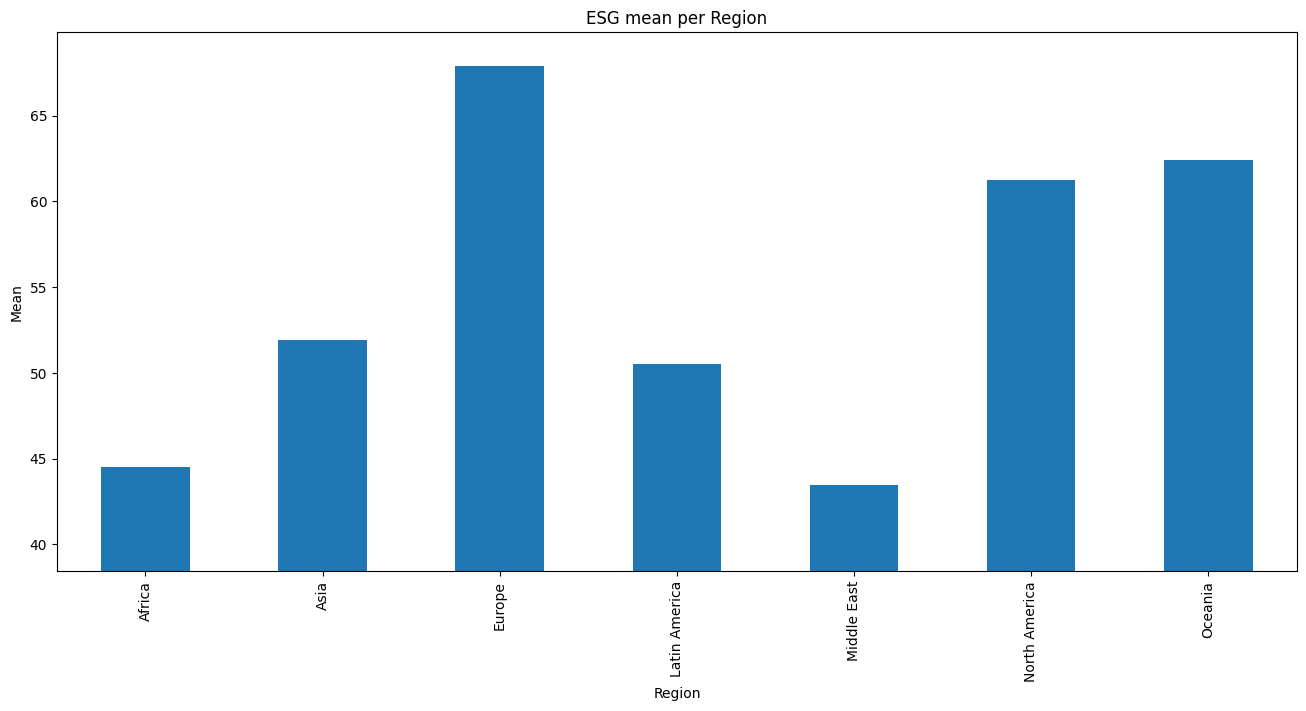

In [107]:
esg_region = companies_cleaned.groupby("Region")[["ESG_Overall", "MarketCap"]].mean()
plt.figure(figsize=(16,7))
esg_region["ESG_Overall"].plot(kind="bar")
plt.title("ESG mean per Region")
plt.ylabel("Mean")
min_esg, max_esg = esg_region["ESG_Overall"].min(), esg_region["ESG_Overall"].max()
plt.ylim(min_esg - 5, max_esg + 2 )
plt.show()

**Note:**
Europe accumulates the **highest average ESG scores**, whereas the Middle East has the **lowest average ESG scores**.

This regional comparison highlights potential geographic differences in sustainability practices, which could inform investment or policy decisions.

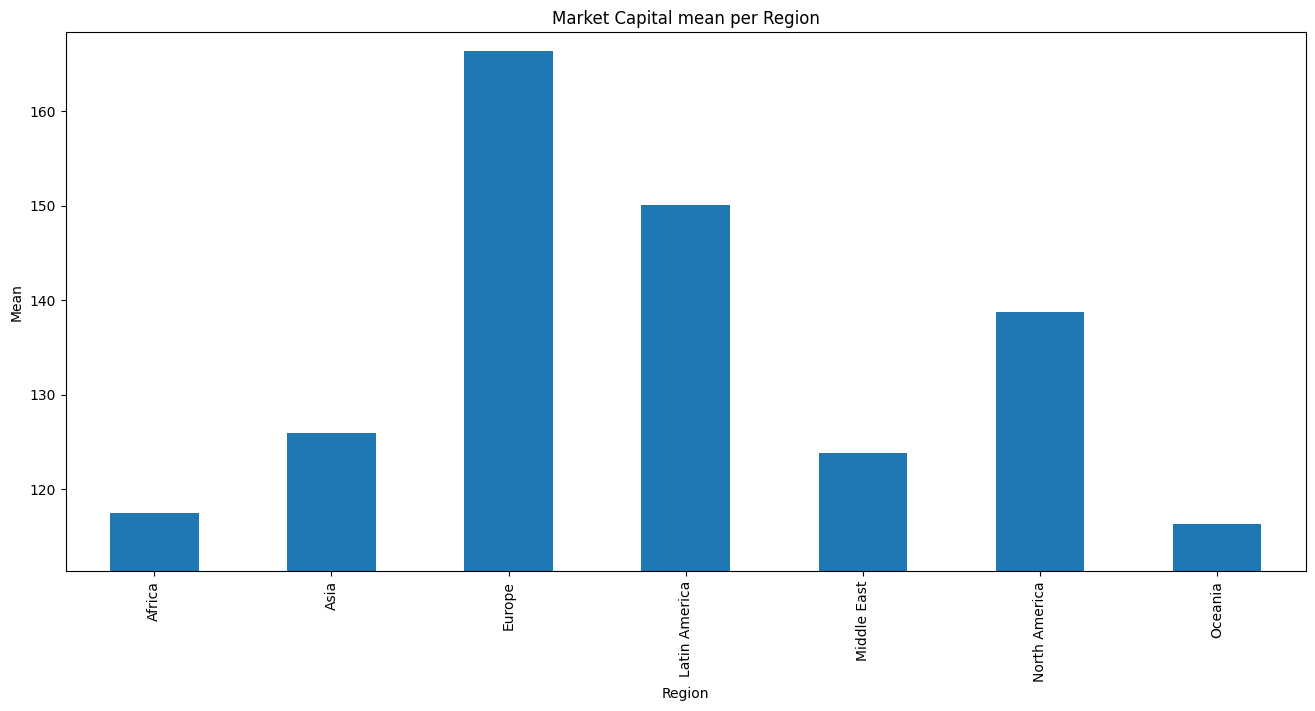

In [109]:
esg_region["MarketCap"] = esg_region["MarketCap"] / 100
plt.figure(figsize=(16,7))
esg_region["MarketCap"].plot(kind="bar")
plt.title("Market Capital mean per Region")
plt.ylabel("Mean")
min_esg, max_esg = esg_region["MarketCap"].min(), esg_region["MarketCap"].max()
plt.ylim(min_esg - 5, max_esg + 2 )
plt.show()

In [110]:
companies_cleaned.pivot_table(values=["ESG_Overall", "ProfitMargin", "MarketCap"], index="Region", columns="Industry")

ESG_Overall                                                 \
Industry      Consumer Goods     Energy    Finance Healthcare Manufacturing   
Region                                                                        
Africa             44.655758  40.419697  54.576970  42.637762     39.495758   
Asia               52.996172  43.793706  62.041414  53.360428     49.189394   
Europe             66.374242  64.456061  78.818687  71.796651     60.704242   
Latin America      48.877273  41.394886  63.721818  52.203977     46.696503   
Middle East        40.626446  36.870455  51.072727  45.399043     40.571717   
North America      59.766986  53.162567  71.290210  63.144805     54.315311   
Oceania            63.435985  59.142208  73.210606  66.102372     60.335885   

                                                                   MarketCap  \
Industry          Retail Technology Transportation  Utilities Consumer Goods   
Region                                                                         
Africa         51.094805  50.961039      36.794697  40.385561    3167.647879   
Asia           58.388636  53.063636      47.003557  46.102597    3314.645455   
Europe         66.749432  77.914286      61.739669  59.594118    5623.925758   
Latin America  50.533766  58.989256      40.324747  52.146853    3747.312500   
Middle East    41.560606  58.346753      35.189328  44.101818    5945.347934   
North America  63.509091  68.448128      62.582576  58.949697    4409.789952   
Oceania        60.003247  76.480992      49.893939  59.535227    4210.252273   

               ...                ProfitMargin                        \
Industry       ...    Utilities Consumer Goods     Energy    Finance   
Region         ...                                                     
Africa         ...  1534.758289      10.163030   7.142424  16.889091   
Asia           ...  1281.286364      11.196651  15.313986  14.502525   
Europe         ...  1488.297326      11.103788   6.607576  13.775253   
Latin America  ...  1584.581818       9.321023  10.959659  14.336818   
Middle East    ...  1508.303636      13.333884  12.082576  12.449198   
North America  ...  1153.359394      11.210048  12.173797  11.851049   
Oceania        ...  2123.332955      10.260227  11.825325  16.650758   

                                                                            \
Industry      Healthcare Manufacturing    Retail Technology Transportation   
Region                                                                       
Africa         18.993706      8.689091  3.832468  19.285714       8.273485   
Asia           14.749733     10.190909  5.802841  19.655195       4.625692   
Europe         17.773684      8.287273  4.207386  18.940909       0.949587   
Latin America  11.971591      9.086713  6.375974  16.096694       5.578788   
Middle East    14.089952      9.005051  5.814141  20.190909       5.533597   
North America  14.009740      7.727751  7.318831  18.921390       7.205303   
Oceania        16.446640      6.742105  5.109091  17.647107       5.415152   

                          
Industry       Utilities  
Region                    
Africa         10.468984  
Asia           10.183766  
Europe          7.967914  
Latin America  10.336364  
Middle East     9.044848  
North America  10.163030  
Oceania         9.805114  

[7 rows x 27 columns]

## 4. Quelles sont les 10 entreprises les plus performantes en combinant ESG et performance financière ?
**Objectif**: Créer un classement des entreprises modèles pour un portefeuille durable.

In [114]:
companies_sorted = companies_cleaned[["CompanyName", "ESG_Overall", "ProfitMargin", "MarketCap"]].sort_values(by=["ESG_Overall", "ProfitMargin", "MarketCap"], ascending=[False, False, False])
companies_sorted.iloc[:10]

,CompanyName,ESG_Overall,ProfitMargin,MarketCap
5255,Company_478,98.8,9.8,12115.6
5256,Company_478,98.3,10.6,13965.0
5252,Company_478,98.2,11.6,16094.0
5257,Company_478,98.0,7.9,15330.3
5254,Company_478,97.8,8.8,12644.8
5253,Company_478,97.7,9.7,20031.1
5251,Company_478,96.9,10.7,22787.5
5250,Company_478,96.7,11.7,24150.1
5189,Company_472,96.3,18.4,18000.0
3877,Company_353,96.0,31.1,11958.5
